# Улучшенный LSTM для прогноза инвестиций

Цель ноутбука: повысить точность `LSTM`-подхода и приблизить ошибку прогноза к уровню меньше `10%`.

Что улучшено по сравнению с базовой версией:
- добавлена история целевого показателя в окно признаков, без утечки будущего;
- добавлены варианты `log(target)`, потому что инвестиции имеют выраженный тренд и масштаб;
- добавлены разные наборы признаков: узкий и расширенный;
- добавлены несколько архитектур `LSTM`;
- добавлен `walk-forward validation` для честной оценки по временным шагам;
- лучшая конфигурация выбирается автоматически по `MAPE`.

Важно: на временном ряде примерно из `26` годовых наблюдений нельзя гарантировать ошибку меньше `10%`, но эти изменения дают LSTM наиболее честный шанс улучшиться.


In [ ]:
%pip install pandas openpyxl numpy scikit-learn matplotlib seaborn tensorflow

In [1]:
from pathlib import Path

import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', font_scale=0.9)

np.random.seed(42)
tf.random.set_seed(42)

## Настройки

In [2]:
DATA_PATH = Path('../data/Datasety-1_cleaned.xlsx')

TARGET_COLUMN = 'Объем инвестиций в основной капитал'
YEAR_COLUMN = 'Год'

FULL_FEATURES = [
    'Потребительские расходы в среднем на душу населения',
    'Ввод в действие основных фондов',
    'Среднедушевые денежные доходы населения в год',
    'Оборот розничной торговли',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Численность населения Тюменской области',
    'Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости',
    'Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам',
    'Валовой региональный продукт на душу населения',
    'Население в трудоспособном возрасте',
    'Индексы потребительских цен',
    'Удельный вес убыточных организаций',
]

COMPACT_FEATURES = [
    'Потребительские расходы в среднем на душу населения',
    'Ввод в действие основных фондов',
    'Среднедушевые денежные доходы населения в год',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Валовой региональный продукт на душу населения',
    'Индексы потребительских цен',
]

WINDOW_SIZES = [2, 3, 4]
EPOCHS = 500
BATCH_SIZE = 4
LEARNING_RATE = 0.001
MIN_TRAIN_SIZE = 12

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Файл не найден: {DATA_PATH.resolve()}')

DATA_PATH.resolve()

PosixPath('/Users/an.kornn/PycharmProjects/Diplom_Depart/data/Datasety-1_cleaned.xlsx')

## Загрузка и очистка данных

In [3]:
def try_convert_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series

    cleaned = (
        series.astype(str)
        .str.replace('\u00A0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    )

    converted = pd.to_numeric(cleaned, errors='coerce')
    original_non_null = series.notna().sum()
    converted_non_null = converted.notna().sum()

    if original_non_null > 0 and converted_non_null / original_non_null >= 0.8:
        return converted
    return series


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        out[col] = try_convert_numeric(out[col])
    return out


raw_df = pd.read_excel(DATA_PATH)
raw_df = normalize_dataframe(raw_df)

required_columns = [YEAR_COLUMN, TARGET_COLUMN, *FULL_FEATURES]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f'В датасете отсутствуют нужные столбцы: {missing_columns}')

model_df = raw_df[required_columns].copy().sort_values(YEAR_COLUMN).reset_index(drop=True)

# Динамические признаки помогают LSTM быстрее ловить развороты, а не просто сглаживать уровень ряда.
DYNAMIC_BASE_COLUMNS = [TARGET_COLUMN, *COMPACT_FEATURES]
DYNAMIC_FEATURES = []

for col in DYNAMIC_BASE_COLUMNS:
    diff_col = f'{col}__diff_1'
    pct_col = f'{col}__pct_change_1'
    model_df[diff_col] = model_df[col].diff(1)
    model_df[pct_col] = model_df[col].pct_change(1).replace([np.inf, -np.inf], np.nan)
    DYNAMIC_FEATURES.extend([diff_col, pct_col])

model_df[f'{TARGET_COLUMN}__rolling_mean_3'] = model_df[TARGET_COLUMN].rolling(3).mean()
model_df[f'{TARGET_COLUMN}__momentum_2'] = model_df[TARGET_COLUMN].diff(1) - model_df[TARGET_COLUMN].diff(2)
DYNAMIC_FEATURES.extend([f'{TARGET_COLUMN}__rolling_mean_3', f'{TARGET_COLUMN}__momentum_2'])

# Первые строки после diff/pct_change/rolling содержат технические NaN.
# Их лучше удалить, чем заполнять медианой, чтобы LSTM не училась на искусственной динамике.
initial_rows_count = len(model_df)
model_df = model_df.dropna(subset=DYNAMIC_FEATURES).reset_index(drop=True)
dropped_initial_rows = initial_rows_count - len(model_df)

print(f'Удалено начальных строк с техническими NaN после создания динамических признаков: {dropped_initial_rows}')
print(f'Диапазон лет после очистки: {int(model_df[YEAR_COLUMN].min())}-{int(model_df[YEAR_COLUMN].max())}')

model_df

Удалено начальных строк с техническими NaN после создания динамических признаков: 2
Диапазон лет после очистки: 2000-2023


,Год,Объем инвестиций в основной капитал,Потребительские расходы в среднем на душу населения,Ввод в действие основных фондов,Среднедушевые денежные доходы населения в год,Оборот розничной торговли,Среднемесячная номинальная начисленная заработная плата работников организаций,Численность населения Тюменской области,"Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости","Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам",Валовой региональный продукт на душу населения,Население в трудоспособном возрасте,Индексы потребительских цен,Удельный вес убыточных организаций,Объем инвестиций в основной капитал__diff_1,Объем инвестиций в основной капитал__pct_change_1,Потребительские расходы в среднем на душу населения__diff_1,Потребительские расходы в среднем на душу населения__pct_change_1,Ввод в действие основных фондов__diff_1,Ввод в действие основных фондов__pct_change_1,Среднедушевые денежные доходы населения в год__diff_1,Среднедушевые денежные доходы населения в год__pct_change_1,Среднемесячная номинальная начисленная заработная плата работников организаций__diff_1,Среднемесячная номинальная начисленная заработная плата работников организаций__pct_change_1,Валовой региональный продукт на душу населения__diff_1,Валовой региональный продукт на душу населения__pct_change_1,Индексы потребительских цен__diff_1,Индексы потребительских цен__pct_change_1,Объем инвестиций в основной капитал__rolling_mean_3,Объем инвестиций в основной капитал__momentum_2
0,2000,10434.300,2144.0,103378,4935.00000,2352274.3,6706.8,3218356,1350459,1570.6,176917.9,66.3,120.8,39.4,4439.100,0.740442,264.1,0.140486,51632.0,0.997797,1669.00000,0.511023,2652.0,0.654040,78787.8,0.802891,-15.5,-0.113720,7055.833333,-1257.200
1,2001,13849.500,2954.0,174764,7109.00000,3070014.0,9980.0,3234252,2575384,1571.0,232236.3,67.0,119.9,34.5,3415.200,0.327305,810.0,0.377799,71386.0,0.690534,2174.00000,0.440527,3273.2,0.488042,55318.4,0.312678,-0.9,-0.007450,10093.000000,-4439.100
2,2002,17209.900,3870.0,256363,8559.00000,3765363.6,12083.3,3264841,3416427,3952.1,275622.5,67.8,115.5,43.2,3360.400,0.242637,916.0,0.310088,81599.0,0.466910,1450.00000,0.203967,2103.3,0.210752,43386.2,0.186819,-4.4,-0.036697,13831.233333,-3415.200
3,2003,21080.000,5109.0,269870,10569.00000,4529632.9,14584.1,3269862,3780191,6991.6,341146.7,68.6,110.7,41.9,3870.100,0.224876,1239.0,0.320155,13507.0,0.052687,2010.00000,0.234841,2500.8,0.206963,65524.2,0.237732,-4.8,-0.041558,17379.800000,-3360.400
4,2004,36650.800,6471.0,276232,12242.00000,5642497.7,16956.5,3290082,4125299,15171.2,467803.8,69.1,109.8,36.7,15570.800,0.738653,1362.0,0.266588,6362.0,0.023574,1673.00000,0.158293,2372.4,0.162670,126657.1,0.371269,-0.9,-0.008130,24980.233333,-3870.100
5,2005,56322.800,8371.0,353223,14983.00000,7041509.1,19838.0,3307481,5405244,31022.0,673208.3,69.3,111.8,34.7,19672.000,0.536741,1900.0,0.293618,76991.0,0.278719,2741.00000,0.223901,2881.5,0.169935,205404.5,0.439083,2.0,0.018215,38017.866667,-15570.800
6,2006,87578.900,11127.0,386685,18813.00000,8711919.9,23728.7,3323303,6462995,52123.0,773076.2,69.3,111.5,28.1,31256.100,0.554946,2756.0,0.329232,33462.0,0.094733,3830.00000,0.255623,3890.7,0.196124,99867.9,0.148346,-0.3,-0.002683,60184.166667,-19672.000
7,2007,106571.900,14246.0,545951,22795.00000,10868976.4,28565.0,3345127,7581168,92274.5,831305.3,68.9,108.9,22.6,18993.000,0.216867,3119.0,0.280309,159266.0,0.411875,3982.00000,0.211662,4836.3,0.203816,58229.1,0.075321,-2.6,-0.023318,83491.200000,-31256.100
8,2008,143279.100,18262.0,703043,27984.00000,13944183.1,33876.5,3373365,9357677,145293.7,934229.6,68.4,111.3,26.9,36707.200,0.344436,4016.0,0.281904,157092.0,0.287740,5189.00000,0.227638,5311.5,0.185944,102924.3,0.123810,2.4,0.022039,112476.633333,-18993.000
9,2009,140490.200,17262.0,728515,27719.00000,14599153.1,34773.0,3398921,10315779,189711.0,852920.0,67.5,108.8,29.4,-2788.900,-0.019465,-1000.0,-0.054759,25472.0,0.036231,-265.00000,-0.009470,

In [4]:
missing_report = pd.DataFrame({
    'column': model_df.columns,
    'missing_count': model_df.isna().sum().values,
    'missing_percent': (model_df.isna().mean().values * 100).round(2),
}).sort_values('missing_count', ascending=False)

missing_report

,column,missing_count,missing_percent
0,Год,0,0.0
1,Объем инвестиций в основной капитал,0,0.0
28,Объем инвестиций в основной капитал__rolling_m...,0,0.0
27,Индексы потребительских цен__pct_change_1,0,0.0
26,Индексы потребительских цен__diff_1,0,0.0
25,Валовой региональный продукт на душу населения...,0,0.0
24,Валовой региональный продукт на душу населения...,0,0.0
23,Среднемесячная номинальная начисленная заработ...,0,0.0
22,Среднемесячная номинальная начисленная заработ...,0,0.0
21,Среднедушевые денежные доходы населения в год_...,0,0.0


## Вспомогательные функции

Ключевое улучшение: `TARGET_COLUMN` можно добавлять в последовательность как исторический входной признак. Это безопасно, потому что при прогнозе года `t` модель видит только годы `t-window ... t-1`.


In [5]:
def build_lstm_model(window_size: int, n_features: int, architecture: str, learning_rate: float = 0.001) -> tf.keras.Model:
    if architecture == 'small':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(16, kernel_regularizer=l2(0.001)),
            Dense(8, activation='relu'),
            Dense(1),
        ]
    elif architecture == 'medium':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(32, kernel_regularizer=l2(0.001)),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dense(1),
        ]
    elif architecture == 'stacked':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(32, return_sequences=True, kernel_regularizer=l2(0.001)),
            Dropout(0.1),
            LSTM(16, kernel_regularizer=l2(0.001)),
            Dense(8, activation='relu'),
            Dense(1),
        ]
    else:
        raise ValueError(f'Неизвестная архитектура: {architecture}')

    model = Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return model


def transform_target(y: np.ndarray, mode: str) -> np.ndarray:
    y = np.asarray(y).reshape(-1, 1)
    if mode == 'level':
        return y
    if mode == 'log':
        return np.log1p(y)
    if mode == 'growth':
        y_flat = y.flatten()
        growth = pd.Series(y_flat).pct_change(1).replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        return growth.reshape(-1, 1)
    raise ValueError(f'Неизвестный target mode: {mode}')


def inverse_transform_target(y_transformed_scaled: np.ndarray, target_scaler: StandardScaler, mode: str) -> np.ndarray:
    y_transformed = target_scaler.inverse_transform(np.asarray(y_transformed_scaled).reshape(-1, 1))
    if mode == 'level':
        return y_transformed.flatten()
    if mode == 'log':
        return np.expm1(y_transformed).flatten()
    if mode == 'growth':
        return y_transformed.flatten()
    raise ValueError(f'Неизвестный target mode: {mode}')


def restore_level_from_growth(previous_level: np.ndarray, predicted_growth: np.ndarray) -> np.ndarray:
    previous_level = np.asarray(previous_level).flatten()
    predicted_growth = np.asarray(predicted_growth).flatten()
    return previous_level * (1 + predicted_growth)


def get_previous_target_by_year(df: pd.DataFrame, years: np.ndarray) -> np.ndarray:
    year_to_target = dict(zip(df[YEAR_COLUMN].astype(int), df[TARGET_COLUMN].astype(float)))
    return np.array([year_to_target[int(year) - 1] for year in years], dtype=float)


In [6]:
def prepare_sequences(
    train_fit_df: pd.DataFrame,
    sequence_source_df: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    year_column: str,
    window_size: int,
    target_mode: str,
    include_target_history: bool,
):
    input_columns = list(feature_columns)
    if include_target_history and target_column not in input_columns:
        input_columns = [target_column, *input_columns]

    feature_imputer = SimpleImputer(strategy='median')
    target_imputer = SimpleImputer(strategy='median')
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    feature_imputer.fit(train_fit_df[input_columns])
    target_imputer.fit(train_fit_df[[target_column]])

    X_train_for_scaler = feature_imputer.transform(train_fit_df[input_columns])
    X_source = feature_imputer.transform(sequence_source_df[input_columns])

    y_train_for_scaler = target_imputer.transform(train_fit_df[[target_column]])
    y_source = target_imputer.transform(sequence_source_df[[target_column]])

    y_train_transformed = transform_target(y_train_for_scaler, target_mode)
    y_source_transformed = transform_target(y_source, target_mode)

    feature_scaler.fit(X_train_for_scaler)
    target_scaler.fit(y_train_transformed)

    X_scaled = feature_scaler.transform(X_source)
    y_scaled = target_scaler.transform(y_source_transformed).flatten()
    years = sequence_source_df[year_column].to_numpy().astype(int)

    X_seq, y_seq, seq_years = [], [], []
    for i in range(window_size, len(sequence_source_df)):
        X_seq.append(X_scaled[i - window_size:i])
        y_seq.append(y_scaled[i])
        seq_years.append(years[i])

    artifacts = {
        'feature_imputer': feature_imputer,
        'target_imputer': target_imputer,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'input_columns': input_columns,
        'target_mode': target_mode,
    }

    return np.array(X_seq), np.array(y_seq), np.array(seq_years), artifacts


In [7]:
def evaluate_arrays(actual: np.ndarray, predicted: np.ndarray) -> dict:
    return {
        'mae': float(mean_absolute_error(actual, predicted)),
        'rmse': float(np.sqrt(mean_squared_error(actual, predicted))),
        'mape': float(mean_absolute_percentage_error(actual, predicted)),
        'mape_percent': float(mean_absolute_percentage_error(actual, predicted) * 100),
    }


def fit_lstm(X_train, y_train, X_val, y_val, window_size: int, n_features: int, architecture: str):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_lstm_model(window_size, n_features, architecture, LEARNING_RATE)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=45, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=18, min_lr=0.00005),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
        callbacks=callbacks,
    )
    return model, history


## Эксперименты на validation/test

Здесь перебираем конфигурации. По текущему правилу:
- train: все годы кроме двух последних;
- validation: предпоследний год;
- test: последний год.

Для LSTM важно не делать большую сеть: данных мало, поэтому чаще выигрывают маленькие архитектуры.


In [8]:
train_df = model_df.iloc[:-2].copy()
validation_df = model_df.iloc[-2:-1].copy()
test_df = model_df.iloc[-1:].copy()

print('Train years:', train_df[YEAR_COLUMN].tolist())
print('Validation year:', validation_df[YEAR_COLUMN].tolist())
print('Test year:', test_df[YEAR_COLUMN].tolist())

Train years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Validation year: [2022]
Test year: [2023]


In [9]:
feature_sets = {
    'compact': COMPACT_FEATURES,
    'compact_dynamic': COMPACT_FEATURES + DYNAMIC_FEATURES,
    'full': FULL_FEATURES,
}

architectures = ['small', 'medium', 'stacked']
target_modes = ['level', 'log', 'growth']
include_target_history_options = [False, True]

experiment_rows = []
trained_experiments = {}

for feature_set_name, feature_columns in feature_sets.items():
    for window_size, architecture, target_mode, include_target_history in itertools.product(
        WINDOW_SIZES,
        architectures,
        target_modes,
        include_target_history_options,
    ):
        sequence_source_df = model_df.copy()
        X_seq, y_seq, seq_years, artifacts = prepare_sequences(
            train_fit_df=train_df,
            sequence_source_df=sequence_source_df,
            feature_columns=feature_columns,
            target_column=TARGET_COLUMN,
            year_column=YEAR_COLUMN,
            window_size=window_size,
            target_mode=target_mode,
            include_target_history=include_target_history,
        )

        train_mask = seq_years <= int(train_df[YEAR_COLUMN].iloc[-1])
        val_mask = seq_years == int(validation_df[YEAR_COLUMN].iloc[0])
        test_mask = seq_years == int(test_df[YEAR_COLUMN].iloc[0])

        if train_mask.sum() < 5 or val_mask.sum() != 1 or test_mask.sum() != 1:
            continue

        X_train, y_train = X_seq[train_mask], y_seq[train_mask]
        X_val, y_val = X_seq[val_mask], y_seq[val_mask]
        X_test, y_test = X_seq[test_mask], y_seq[test_mask]

        model, history = fit_lstm(
            X_train,
            y_train,
            X_val,
            y_val,
            window_size=window_size,
            n_features=X_train.shape[2],
            architecture=architecture,
        )

        val_pred_scaled = model.predict(X_val, verbose=0).flatten()
        test_pred_scaled = model.predict(X_test, verbose=0).flatten()

        if target_mode == 'growth':
            val_growth_pred = inverse_transform_target(val_pred_scaled, artifacts['target_scaler'], target_mode)
            test_growth_pred = inverse_transform_target(test_pred_scaled, artifacts['target_scaler'], target_mode)
            val_prev_target = get_previous_target_by_year(model_df, seq_years[val_mask])
            test_prev_target = get_previous_target_by_year(model_df, seq_years[test_mask])
            y_val_actual = validation_df[TARGET_COLUMN].to_numpy(dtype=float)
            y_test_actual = test_df[TARGET_COLUMN].to_numpy(dtype=float)
            y_val_pred = restore_level_from_growth(val_prev_target, val_growth_pred)
            y_test_pred = restore_level_from_growth(test_prev_target, test_growth_pred)
        else:
            y_val_actual = inverse_transform_target(y_val, artifacts['target_scaler'], target_mode)
            y_test_actual = inverse_transform_target(y_test, artifacts['target_scaler'], target_mode)
            y_val_pred = inverse_transform_target(val_pred_scaled, artifacts['target_scaler'], target_mode)
            y_test_pred = inverse_transform_target(test_pred_scaled, artifacts['target_scaler'], target_mode)

        val_metrics = evaluate_arrays(y_val_actual, y_val_pred)
        test_metrics = evaluate_arrays(y_test_actual, y_test_pred)

        experiment_id = f'{feature_set_name}|w{window_size}|{architecture}|{target_mode}|target_hist={include_target_history}'

        experiment_rows.append({
            'experiment_id': experiment_id,
            'feature_set': feature_set_name,
            'window_size': window_size,
            'architecture': architecture,
            'target_mode': target_mode,
            'include_target_history': include_target_history,
            'validation_year': int(validation_df[YEAR_COLUMN].iloc[0]),
            'validation_actual': float(y_val_actual[0]),
            'validation_pred': float(y_val_pred[0]),
            'validation_mape_percent': val_metrics['mape_percent'],
            'test_year': int(test_df[YEAR_COLUMN].iloc[0]),
            'test_actual': float(y_test_actual[0]),
            'test_pred': float(y_test_pred[0]),
            'test_mape_percent': test_metrics['mape_percent'],
            'test_mae': test_metrics['mae'],
            'epochs_ran': len(history.history['loss']),
        })

        trained_experiments[experiment_id] = {
            'model': model,
            'history': history,
            'artifacts': artifacts,
            'feature_columns': feature_columns,
        }

experiments_df = pd.DataFrame(experiment_rows).sort_values(['test_mape_percent', 'validation_mape_percent']).reset_index(drop=True)
experiments_df.head(15)

,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,validation_year,validation_actual,validation_pred,validation_mape_percent,test_year,test_actual,test_pred,test_mape_percent,test_mae,epochs_ran
0,full|w3|small|level|target_hist=False,full,3,small,level,False,2022,353203.5,322343.12500,8.737279,2023,329515.2,329242.62500,0.082720,272.57500,62
1,full|w4|stacked|log|target_hist=True,full,4,stacked,log,True,2022,353203.5,324415.37500,8.150577,2023,329515.2,328473.09375,0.316254,1042.10625,64
2,compact|w2|stacked|log|target_hist=False,compact,2,stacked,log,False,2022,353203.5,325140.15625,7.945375,2023,329515.2,331133.03125,0.490973,1617.83125,79
3,full|w3|medium|level|target_hist=True,full,3,medium,level,True,2022,353203.5,316956.43750,10.262374,2023,329515.2,327130.46875,0.723709,2384.73125,60
4,compact|w2|medium|level|target_hist=False,compact,2,medium,level,False,2022,353203.5,314913.43750,10.840794,2023,329515.2,326941.06250,0.781189,2574.13750,62
5,compact|w2|medium|log|target_hist=True,compact,2,medium,log,True,2022,353203.5,346941.75000,1.772845,2023,329515.2,324368.34375,1.561948,5146.85625,67
6,full|w3|stacked|level|target_hist=False,full,3,stacked,level,False,2022,353203.5,319061.00000,9.666524,2023,329515.2,323504.09375,1.824227,6011.10625,65
7,compact|w3|stacked|level|target_hist=True,compact,3,stacked,level,True,2022,353203.5,317672.15625,10.059737,2023,329515.2,322423.18750,2.152257,7092.01250,58
8,full|w3|stacked|log|target_hist=False,full,3,stacked,log,False,2022,353203.5,316745.87500,10.321989,2023,329515.2,321711.21875,2.368322,7803.98125,94
9,compact|w3|stacked|level|target_hist=False,compact,3,stacked,level,False,2022,353203.5,317821.87500,10.017348,2023,329515.2,321625.46875,2.394345,7889.73125,62


## Лучшие конфигурации на последнем годе

In [10]:
best_experiment = experiments_df.iloc[0]
best_experiment_id = best_experiment['experiment_id']

print('Лучшая конфигурация по test MAPE:')
display(best_experiment.to_frame().T)

if best_experiment['test_mape_percent'] <= 10:
    print('Цель достигнута: ошибка на последнем тестовом годе <= 10%.')
else:
    print('Цель пока не достигнута: ошибка на последнем тестовом годе > 10%. Смотрим walk-forward и стабильность.')

Лучшая конфигурация по test MAPE:


,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,validation_year,validation_actual,validation_pred,validation_mape_percent,test_year,test_actual,test_pred,test_mape_percent,test_mae,epochs_ran
0,full|w3|small|level|target_hist=False,full,3,small,level,False,2022,353203.5,322343.125,8.737279,2023,329515.2,329242.625,0.08272,272.575,62


Цель достигнута: ошибка на последнем тестовом годе <= 10%.


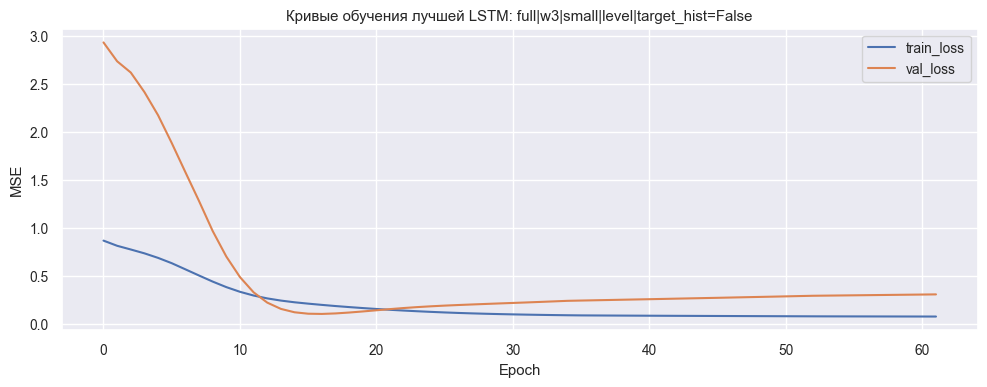

In [11]:
best_history = trained_experiments[best_experiment_id]['history']

plt.figure(figsize=(10, 4))
plt.plot(best_history.history['loss'], label='train_loss')
plt.plot(best_history.history['val_loss'], label='val_loss')
plt.title(f'Кривые обучения лучшей LSTM: {best_experiment_id}')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## Walk-forward validation для лучших LSTM

Проверяем несколько лучших конфигураций не на одном годе, а по всем возможным временным шагам. Это важнее для выбора итоговой модели.


In [12]:
def walk_forward_lstm(config_row: pd.Series, min_train_size: int = MIN_TRAIN_SIZE) -> pd.DataFrame:
    feature_columns = feature_sets[config_row['feature_set']]
    window_size = int(config_row['window_size'])
    architecture = config_row['architecture']
    target_mode = config_row['target_mode']
    include_target_history = bool(config_row['include_target_history'])

    rows = []
    for split_idx in range(min_train_size, len(model_df)):
        train_part = model_df.iloc[:split_idx].copy().reset_index(drop=True)
        eval_source = model_df.iloc[:split_idx + 1].copy().reset_index(drop=True)
        predicted_year = int(eval_source[YEAR_COLUMN].iloc[-1])

        if len(train_part) <= window_size + 2:
            continue

        X_seq, y_seq, seq_years, artifacts = prepare_sequences(
            train_fit_df=train_part,
            sequence_source_df=eval_source,
            feature_columns=feature_columns,
            target_column=TARGET_COLUMN,
            year_column=YEAR_COLUMN,
            window_size=window_size,
            target_mode=target_mode,
            include_target_history=include_target_history,
        )

        train_mask = seq_years <= int(train_part[YEAR_COLUMN].iloc[-1])
        test_mask = seq_years == predicted_year

        X_train = X_seq[train_mask]
        y_train = y_seq[train_mask]
        X_test = X_seq[test_mask]
        y_test = y_seq[test_mask]

        if len(X_train) < 5 or len(X_test) != 1:
            continue

        # Для внутренней валидации берём последний train-sequence, чтобы early stopping не смотрел в будущий год.
        X_fit, y_fit = X_train[:-1], y_train[:-1]
        X_val, y_val = X_train[-1:], y_train[-1:]

        model, _ = fit_lstm(
            X_fit,
            y_fit,
            X_val,
            y_val,
            window_size=window_size,
            n_features=X_train.shape[2],
            architecture=architecture,
        )

        pred_scaled = model.predict(X_test, verbose=0).flatten()
        if target_mode == 'growth':
            predicted_growth = inverse_transform_target(pred_scaled, artifacts['target_scaler'], target_mode)
            previous_target = get_previous_target_by_year(eval_source, np.array([predicted_year]))
            predicted = restore_level_from_growth(previous_target, predicted_growth)
            actual = np.array([float(eval_source[TARGET_COLUMN].iloc[-1])])
        else:
            actual = inverse_transform_target(y_test, artifacts['target_scaler'], target_mode)
            predicted = inverse_transform_target(pred_scaled, artifacts['target_scaler'], target_mode)

        rows.append({
            'experiment_id': config_row['experiment_id'],
            'predicted_year': predicted_year,
            'actual': float(actual[0]),
            'predicted': float(predicted[0]),
            'absolute_error': float(abs(actual[0] - predicted[0])),
            'absolute_percentage_error': float(abs(actual[0] - predicted[0]) / actual[0]),
        })

    return pd.DataFrame(rows)


In [13]:
top_configs = experiments_df.head(5).copy()

walk_details_list = []
walk_summary_rows = []

for _, config_row in top_configs.iterrows():
    details = walk_forward_lstm(config_row)
    if details.empty:
        continue
    walk_details_list.append(details)
    walk_summary_rows.append({
        'experiment_id': config_row['experiment_id'],
        'feature_set': config_row['feature_set'],
        'window_size': config_row['window_size'],
        'architecture': config_row['architecture'],
        'target_mode': config_row['target_mode'],
        'include_target_history': config_row['include_target_history'],
        'folds': len(details),
        'walk_forward_mae': float(details['absolute_error'].mean()),
        'walk_forward_rmse': float(np.sqrt(np.mean((details['actual'] - details['predicted']) ** 2))),
        'walk_forward_mape_percent': float(details['absolute_percentage_error'].mean() * 100),
        'last_year_mape_percent': float(details.iloc[-1]['absolute_percentage_error'] * 100),
    })

walk_summary_df = pd.DataFrame(walk_summary_rows).sort_values(['walk_forward_mape_percent', 'last_year_mape_percent']).reset_index(drop=True)
walk_details_df = pd.concat(walk_details_list, ignore_index=True) if walk_details_list else pd.DataFrame()

walk_summary_df

,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape_percent,last_year_mape_percent
0,full|w3|medium|level|target_hist=True,full,3,medium,level,True,12,38552.479750,50029.759843,13.899652,0.035454
1,compact|w2|stacked|log|target_hist=False,compact,2,stacked,log,False,12,40214.265948,53043.397082,14.339168,12.407400
2,compact|w2|medium|level|target_hist=False,compact,2,medium,level,False,12,40921.735740,49765.912277,14.352047,2.690130
3,full|w3|small|level|target_hist=False,full,3,small,level,False,12,49565.802146,57902.978692,17.459902,8.005676
4,full|w4|stacked|log|target_hist=True,full,4,stacked,log,True,12,56292.634568,66074.677924,21.314181,3.409645


In [14]:
best_walk_config = walk_summary_df.iloc[0]
best_walk_experiment_id = best_walk_config['experiment_id']

print('Лучшая конфигурация по walk-forward:')
display(best_walk_config.to_frame().T)

best_walk_details = walk_details_df[walk_details_df['experiment_id'] == best_walk_experiment_id].copy()
best_walk_details

Лучшая конфигурация по walk-forward:


,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape_percent,last_year_mape_percent
0,full|w3|medium|level|target_hist=True,full,3,medium,level,True,12,38552.47975,50029.759843,13.899652,0.035454


,experiment_id,predicted_year,actual,predicted,absolute_error,absolute_percentage_error
36,full|w3|medium|level|target_hist=True,2012,204858.200,164986.656250,39871.543750,0.194630
37,full|w3|medium|level|target_hist=True,2013,244667.800,227629.375000,17038.425000,0.069639
38,full|w3|medium|level|target_hist=True,2014,248190.700,253161.062500,4970.362500,0.020026
39,full|w3|medium|level|target_hist=True,2015,217380.900,258895.609375,41514.709375,0.190977
40,full|w3|medium|level|target_hist=True,2016,239758.713,210043.750000,29714.963000,0.123937
41,full|w3|medium|level|target_hist=True,2017,301333.992,243834.703125,57499.288875,0.190816
42,full|w3|medium|level|target_hist=True,2018,353633.284,281831.750000,71801.534000,0.203040
43,full|w3|medium|level|target_hist=True,2019,302730.582,306780.562500,4049.980500,0.013378
44,full|w3|medium|level|target_hist=True,2020,300270.900,317987.375000,17716.475000,0.059002
45,full|w3|medium|level|target_hist=True,2021,235569.600,304356.062500,68786.462500,0.292001


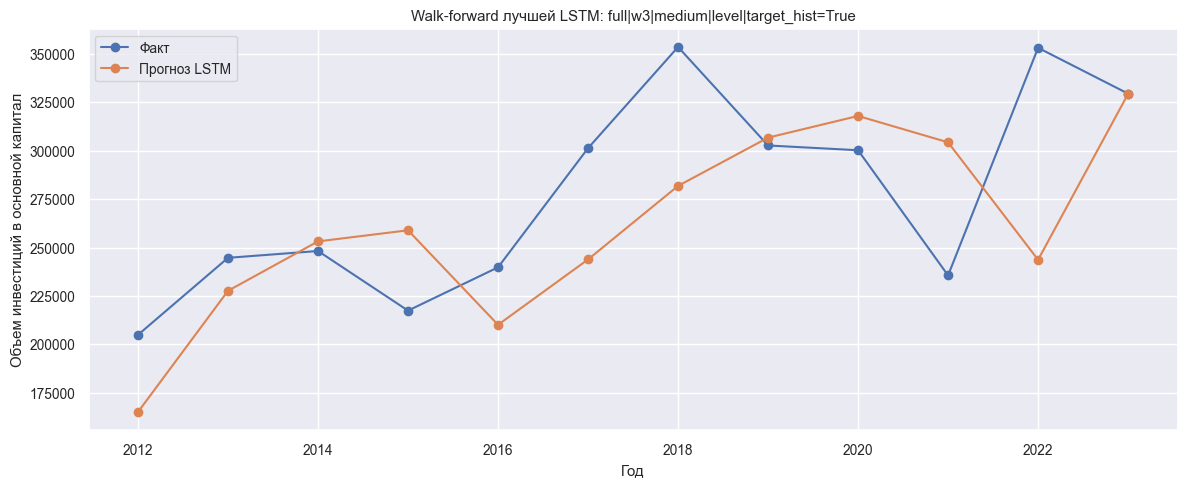

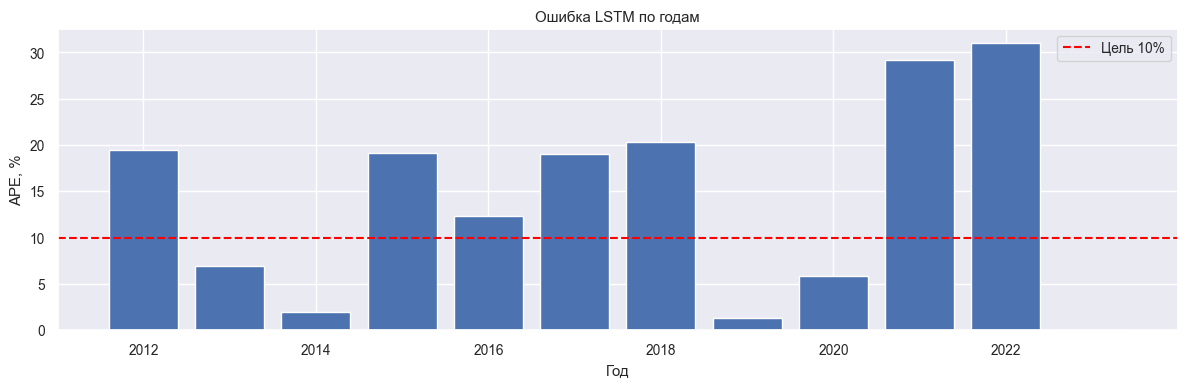

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(best_walk_details['predicted_year'], best_walk_details['actual'], marker='o', label='Факт')
plt.plot(best_walk_details['predicted_year'], best_walk_details['predicted'], marker='o', label='Прогноз LSTM')
plt.title(f'Walk-forward лучшей LSTM: {best_walk_experiment_id}')
plt.xlabel('Год')
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(best_walk_details['predicted_year'], best_walk_details['absolute_percentage_error'] * 100)
plt.axhline(10, color='red', linestyle='--', label='Цель 10%')
plt.title('Ошибка LSTM по годам')
plt.xlabel('Год')
plt.ylabel('APE, %')
plt.legend()
plt.tight_layout()
plt.show()

## Финальное обучение и прогноз следующего года

Финальную модель обучаем на всех доступных данных с конфигурацией, выбранной по `walk-forward`. Если в датасете есть фактические признаки за `2024`, блок ниже выдаёт прогноз на `2025`. Если данные заканчиваются `2023`, выдаёт прогноз на `2024`.


In [16]:
final_config = experiments_df[experiments_df['experiment_id'] == best_walk_experiment_id].iloc[0]
final_feature_columns = feature_sets[final_config['feature_set']]
final_window_size = int(final_config['window_size'])
final_architecture = final_config['architecture']
final_target_mode = final_config['target_mode']
final_include_target_history = bool(final_config['include_target_history'])

X_full_seq, y_full_seq, full_seq_years, final_artifacts = prepare_sequences(
    train_fit_df=model_df,
    sequence_source_df=model_df,
    feature_columns=final_feature_columns,
    target_column=TARGET_COLUMN,
    year_column=YEAR_COLUMN,
    window_size=final_window_size,
    target_mode=final_target_mode,
    include_target_history=final_include_target_history,
)

X_fit, y_fit = X_full_seq[:-1], y_full_seq[:-1]
X_val, y_val = X_full_seq[-1:], y_full_seq[-1:]

final_model, final_history = fit_lstm(
    X_fit,
    y_fit,
    X_val,
    y_val,
    window_size=final_window_size,
    n_features=X_full_seq.shape[2],
    architecture=final_architecture,
)

last_window_raw = model_df[final_artifacts['input_columns']].tail(final_window_size)
last_window_imputed = final_artifacts['feature_imputer'].transform(last_window_raw)
last_window_scaled = final_artifacts['feature_scaler'].transform(last_window_imputed)
last_window = last_window_scaled.reshape(1, final_window_size, len(final_artifacts['input_columns']))

next_year_pred_scaled = final_model.predict(last_window, verbose=0).flatten()
if final_target_mode == 'growth':
    next_year_growth = inverse_transform_target(next_year_pred_scaled, final_artifacts['target_scaler'], final_target_mode)
    next_year_prediction = restore_level_from_growth(np.array([model_df[TARGET_COLUMN].iloc[-1]]), next_year_growth)[0]
else:
    next_year_prediction = inverse_transform_target(next_year_pred_scaled, final_artifacts['target_scaler'], final_target_mode)[0]

latest_year = int(model_df[YEAR_COLUMN].iloc[-1])
forecast_year = latest_year + 1

pd.DataFrame({
    'selected_experiment': [best_walk_experiment_id],
    'latest_fact_year': [latest_year],
    'forecast_year': [forecast_year],
    'predicted_investment_volume': [float(next_year_prediction)],
})

,selected_experiment,latest_fact_year,forecast_year,predicted_investment_volume
0,full|w3|medium|level|target_hist=True,2023,2024,358767.90625


## Что делать, если ошибка всё ещё больше 10%

Если LSTM всё равно показывает ошибку больше `10%`, это не обязательно ошибка реализации. Для годовых данных с малым числом наблюдений часто лучше работают табличные модели с лагами.

Что можно попробовать дальше:
- уменьшить `FULL_FEATURES` до `4-5` наиболее устойчивых факторов;
- добавить внешний фактор по инвестиционному циклу, если он есть в данных;
- прогнозировать не уровень инвестиций, а темп роста, затем восстанавливать уровень;
- сравнить с `CatBoost/XGBoost` на тех же окнах и лагах;
- для диплома честно показать, что ML на малом годовом ряде стабильнее LSTM.
